<span style="font-size:2em; font-weight:bold;"> Grenada Rainfall Analysis: Intensity Duration Frequency (IDF) Curve Development -Peaks-over-threshold (POTS) threshold selection</span>
***

This code was written to select the threshold to be used in POTS across all considered stations using the pyextremes Python package (https://georgebv.github.io/pyextremes). In particular we focus on the Parameter and Return Period stability to select thresholds owing the inherent issues associated with the Mean Life Residual method.

# 1.0 Import modules and data

## 1.1 Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from tqdm.auto import tqdm
from pyextremes import plot_threshold_stability

## 1.2 Import data

In [5]:
# station names and locations
stations = pd.read_excel(r'Data\GRN_RAINFALL_DATA_NAWASA_2025.xlsx',sheet_name='Raingauge Coordinates')

# imputed rainfall data
grn_rainfall_imput = pd.read_csv(r'Data\GRN_RAINFALL_MODELElev_FINAL_n6_thr25mm_var0p25.csv')
grn_rainfall_imput['date'] = pd.to_datetime(grn_rainfall_imput['date'], errors='coerce')
grn_rainfall_imput = grn_rainfall_imput.set_index('date').sort_index()

# get station names from columns
station_ids = grn_rainfall_imput.columns.tolist()

# 2.0 Threshold Selection

## 2.1 Single station test/demonstration

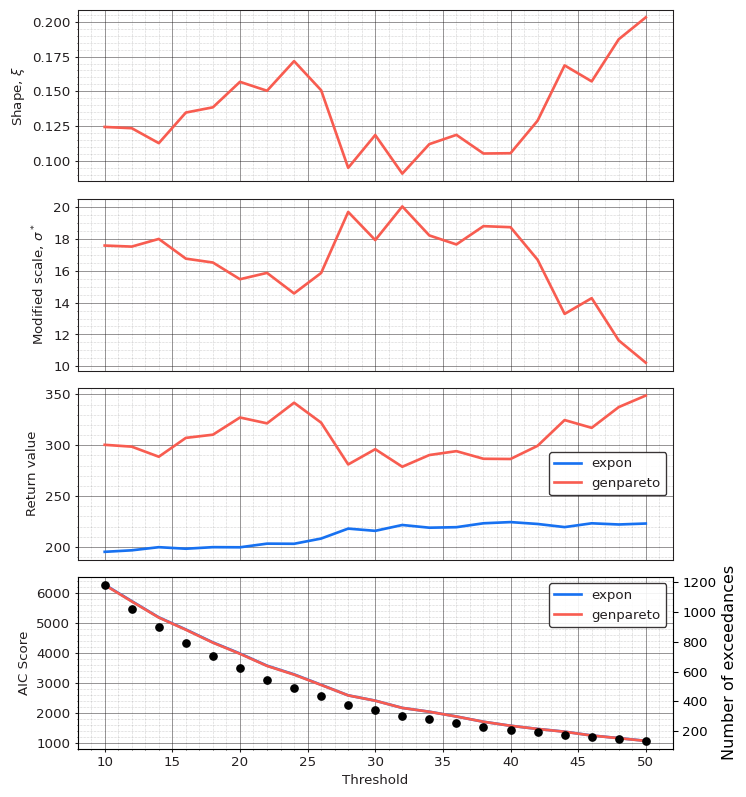

In [7]:
ts = grn_rainfall_imput[station_ids[0]].dropna()
valid_thresholds = [thr for thr in np.linspace(10, 50, 21) if (ts > thr).sum() >= 6]
thr_exc = [(ts > thr).sum() for thr in valid_thresholds]

axes = plot_threshold_stability(
    grn_rainfall_imput[station_ids[0]].dropna(),
    return_period=100,
    thresholds=valid_thresholds
)
for ax in axes:
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

ax_aic = axes[3]
ax2 = ax_aic.twinx()
ax2.scatter(valid_thresholds, thr_exc, color='black', s=30, label='Exceedances')
ax2.set_ylabel("Number of exceedances", fontsize=12)
plt.show()

## 2.2 Loop over all stations

In [8]:
for sta in tqdm(station_ids):
    ts = grn_rainfall_imput[sta].dropna()
    valid_thresholds = [thr for thr in np.linspace(10, 60, 51) if (ts > thr).sum() >= 6]
    thr_exc = [(ts > thr).sum() for thr in valid_thresholds]

    axes = plot_threshold_stability(
        grn_rainfall_imput[sta].dropna(),
        return_period=100,
        thresholds=valid_thresholds
    )
    for ax in axes:
        ax.minorticks_on()
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
        ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

    ax_aic = axes[3]
    ax2 = ax_aic.twinx()
    ax2.scatter(valid_thresholds, thr_exc, color='black', s=30, label='Exceedances')
    ax2.set_ylabel("Number of exceedances", fontsize=12)

    fig = axes[0].figure
    fig.suptitle(f"Station: {sta}", fontsize=18,fontweight='bold')
    plt.savefig(rf"Outputs\POTS_PARAMS_STABILITY_PLOTS\threshold_stability_{sta}.png", dpi=300)
    plt.close('all')

  0%|          | 0/28 [00:00<?, ?it/s]